# FCR Prequalification Study with HydroPowerDynamics.jl

Goal: build one reproducible engineering chain

`HPD nonlinear plant -> reduced linear model -> ControlSystems -> JuMP -> nonlinear HPD verification`.

This is a prequalification *aid*, not an official Statnett qualification decision. The first executable version uses a transparent proxy test definition so the optimization and validation logic can be inspected. Product-specific Nordic/Statnett trajectories and acceptance envelopes belong in a replaceable data layer.

In [1]:
using HydroPowerDynamics
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using ModelingToolkitStandardLibrary
using ModelingToolkitStandardLibrary.Blocks
using OrdinaryDiffEq
using ControlSystemsBase
using JuMP, Ipopt
using DataFrames, CSV
using Plots
using LinearAlgebra, Statistics, Printf

default(size=(820,460), linewidth=2, legend=:best)
plotdir = joinpath(@__DIR__, "plots")
resultdir = joinpath(@__DIR__, "results")
mkpath(plotdir); mkpath(resultdir)
println("FCR study environment loaded")

[ Info: Precompiling HydroPowerDynamics [3b6e4b0c-9b3e-4e2f-8c1a-7f2d5e6a9b4c] 


┌ Warning: the bare singleton variant syntax `ContinuousClock` is deprecated, write `ContinuousClock()` instead (near /home/runner/.julia/packages/SciMLBase/O1HPI/src/clock.jl:4)
│   caller = eval at boot.jl:430 [inlined]
└ @ Core ./boot.jl:430


┌ Warning: the bare singleton variant syntax `Inferred` is deprecated, write `Inferred()` instead (near /home/runner/.julia/packages/ModelingToolkit/JvjlW/src/clock.jl:2)
│   caller = eval at boot.jl:430 [inlined]
└ @ Core ./boot.jl:430


[ Info: Precompiling ControlSystemsBase [aaaaaaaa-a6ca-5380-bf3e-84a91bcd477e] 


[ Info: Precompiling PolynomialsChainRulesCoreExt [f5ad5175-ea71-5bad-b0d8-3d77b6894ccb] 


...

[ Info: Precompiling SpecialFunctionsExt [997ecda8-951a-5f50-90ea-61382e97704b] 


[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] 


[ Info: Precompiling UnitfulExt [0e51ec96-f580-5f12-a625-1297083d7970] 


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] 


FCR study environment loaded


## 1. Trollheim-inspired operating point and proxy FCR test

The nonlinear parameters follow the validated `AGC_Trollheim` work. The test settings below are deliberately centralized. Replace them later by the current Statnett/Nordic product data without changing the plant physics.

In [2]:
const PBASE_MW = 150.0
const P0_MW = 75.0
const F0_HZ = 50.0
const POLES = 16
const W0 = 2π*(120F0_HZ/POLES)/60
const H_GROSS = 371.0
const RHO = 1000.0
const G = 9.81
const P_ATM = 101325.0
const P_UP = P_ATM + RHO*G*H_GROSS
const Q0 = 22.13749950628151
const DM0 = RHO*Q0
const Y0 = 0.5384797177203611
const L_HEADRACE = 500.0
const D_HEADRACE = 6.0
const L_PENSTOCK = 500.0
const D_PENSTOCK = 4.0
const ROUGHNESS = 1.5e-5
const D_RUNNER = 2.5
const Q_RATED = 37.0
const ETA_MAX = 0.97
const C_ETA = 0.25
const KQ = Q_RATED/(0.90*D_RUNNER^2*sqrt(H_GROSS))
const TG = 0.30

# Proxy qualification test (not claimed as regulatory limits)
const DF_FULL_HZ = 0.10
const T_REQ = 5.0
const ALPHA_REQ = 0.90
const T_END = 30.0
const PFCR_MAX_MW = 30.0
const Y_MIN = 0.05
const Y_MAX = 1.00
const DY_OPEN = 0.12
const DY_CLOSE = 0.12
const Q_MIN_PU = 0.70
const Q_MAX_PU = 1.45

A_hr = π*D_HEADRACE^2/4
A_ps = π*D_PENSTOCK^2/4
Tw = L_HEADRACE*Q0/(G*A_hr*H_GROSS) + L_PENSTOCK*Q0/(G*A_ps*H_GROSS)
@printf("Nominal speed = %.4f rad/s\n", W0)
@printf("Water starting time Tw = %.4f s\n", Tw)
@printf("Initial gate = %.4f pu; flow = %.4f m3/s\n", Y0, Q0)

Nominal speed = 39.2699 rad/s
Water starting time Tw = 0.3496 s


Initial gate = 0.5385 pu; flow = 22.1375 m3/s


## 2. Local linear FCR model

Around the operating point,

$\dot{\Delta q}=(\Delta y/y_0-\Delta q)/T_w$,

$\dot{\Delta y}=(-K_f\Delta f-\Delta y)/T_g$,

$\Delta P=P_0\Delta q$.

This gives a cheap screening model. The optimized reserve is only a candidate until the nonlinear HPD plant passes.

Row,real,imag
,Float64,Float64
1,-2.86058,0.0
2,-3.33333,0.0


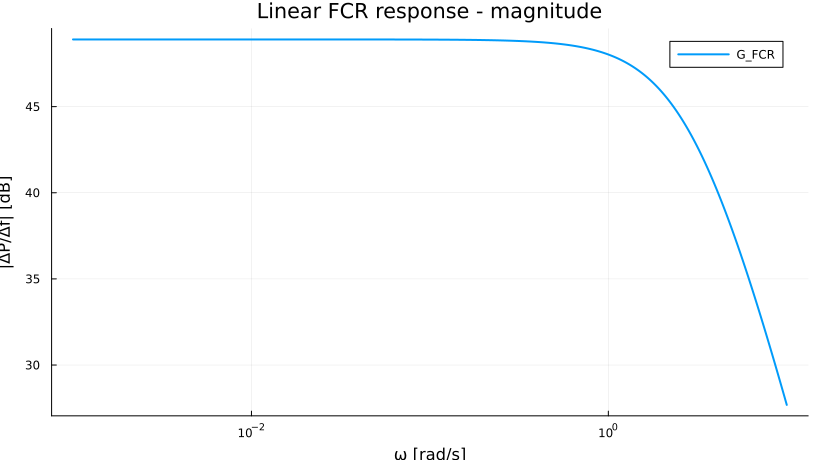

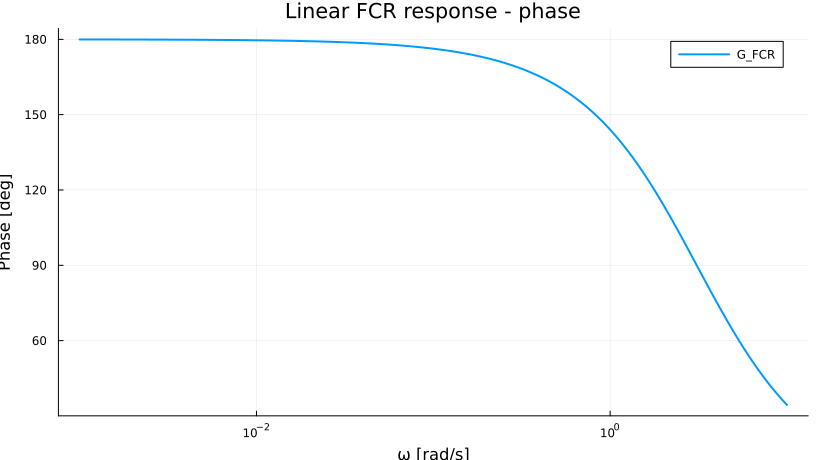

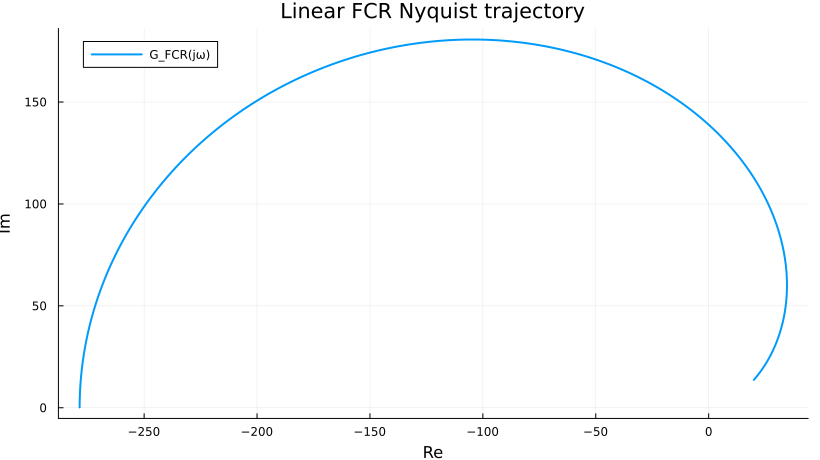

In [3]:
PFCR_design_MW = 15.0
Kf = (PFCR_design_MW/P0_MW)/DF_FULL_HZ
A = [-1/Tw  1/(Tw*Y0); 0.0 -1/TG]
B = [0.0; -Kf/TG]
C = [P0_MW 0.0]
D0 = [0.0]
Gfcr = ss(A,B,C,D0)
λ = poles(Gfcr)
display(DataFrame(real=real.(λ), imag=imag.(λ)))
w = exp10.(range(-3,1,length=800))
resp = vec(freqresp(Gfcr,w))
mag_db = 20 .* log10.(abs.(resp))
phase_deg = rad2deg.(angle.(resp))
p1 = plot(w,mag_db,xscale=:log10,xlabel="ω [rad/s]",ylabel="|ΔP/Δf| [dB]",title="Linear FCR response - magnitude",label="G_FCR")
savefig(p1,joinpath(plotdir,"01_linear_bode_magnitude.png")); display(p1)
p2 = plot(w,phase_deg,xscale=:log10,xlabel="ω [rad/s]",ylabel="Phase [deg]",title="Linear FCR response - phase",label="G_FCR")
savefig(p2,joinpath(plotdir,"02_linear_bode_phase.png")); display(p2)
p3 = plot(real.(resp),imag.(resp),xlabel="Re",ylabel="Im",title="Linear FCR Nyquist trajectory",label="G_FCR(jω)")
savefig(p3,joinpath(plotdir,"03_linear_nyquist.png")); display(p3)

## 3. JuMP formulation

Maximize offered reserve $P_{FCR}$ subject to reduced dynamics, guide-vane limits, guide-vane rate, hydraulic flow and dynamic delivery. The active constraint is recorded as an engineering diagnostic.


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

JuMP status = LOCALLY_SOLVED
Candidate FCR = 2.7000 MW


Linear 5 s delivery = 5.0141 MW (185.7%)


Row,constraint,margin
,String,Float64
1,upper gate,0.42552
2,upper flow,0.383145
3,5 s delivery,2.58411
4,opening rate,-1.99889e-7


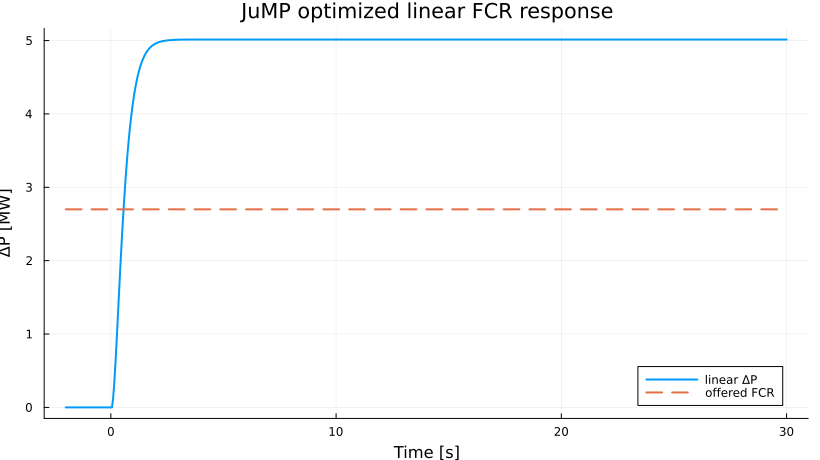

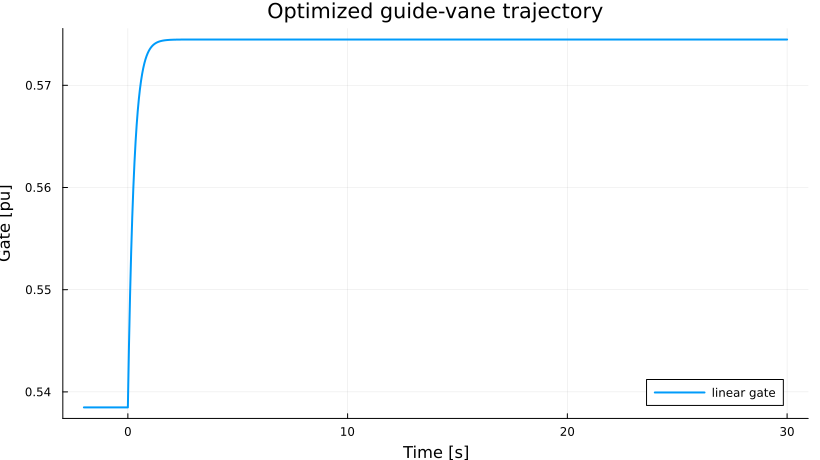

In [4]:
dt = 0.05
times = collect(-2.0:dt:T_END)
N = length(times)
df = [tt < 0 ? 0.0 : -DF_FULL_HZ for tt in times]
kreq = argmin(abs.(times .- T_REQ))
m = Model(Ipopt.Optimizer)
set_silent(m)
@variable(m,0 <= PFCR <= PFCR_MAX_MW)
@variable(m,Y_MIN <= y[1:N] <= Y_MAX)
@variable(m,Q_MIN_PU <= q[1:N] <= Q_MAX_PU)
@constraint(m,y[1] == Y0)
@constraint(m,q[1] == 1.0)
for k in 1:N-1
    ycmd = Y0 - (PFCR/P0_MW)*(df[k]/DF_FULL_HZ)
    @constraint(m,y[k+1] == y[k] + dt/TG*(ycmd-y[k]))
    @constraint(m,q[k+1] == q[k] + dt/Tw*(y[k]/Y0-q[k]))
    @constraint(m,y[k+1]-y[k] <= DY_OPEN*dt)
    @constraint(m,y[k]-y[k+1] <= DY_CLOSE*dt)
end
@constraint(m,P0_MW*(q[kreq]-1) >= ALPHA_REQ*PFCR)
@constraint(m,P0_MW*(q[end]-1) >= 0.98*PFCR)
@objective(m,Max,PFCR)
optimize!(m)
PFCR_star = value(PFCR)
yv = value.(y); qv = value.(q)
dPv = P0_MW .* (qv .- 1)
rate = diff(yv)./dt
@printf("JuMP status = %s\n",string(termination_status(m)))
@printf("Candidate FCR = %.4f MW\n",PFCR_star)
@printf("Linear 5 s delivery = %.4f MW (%.1f%%)\n",dPv[kreq],100dPv[kreq]/PFCR_star)
diag = DataFrame(constraint=["upper gate","upper flow","5 s delivery","opening rate"],margin=[Y_MAX-maximum(yv),Q_MAX_PU-maximum(qv),dPv[kreq]-ALPHA_REQ*PFCR_star,DY_OPEN-maximum(rate)])
display(diag)
p4 = plot(times,dPv,xlabel="Time [s]",ylabel="ΔP [MW]",title="JuMP optimized linear FCR response",label="linear ΔP")
plot!(p4,times,fill(PFCR_star,N),linestyle=:dash,label="offered FCR")
savefig(p4,joinpath(plotdir,"04_jump_linear_response.png")); display(p4)
p5 = plot(times,yv,xlabel="Time [s]",ylabel="Gate [pu]",title="Optimized guide-vane trajectory",label="linear gate")
savefig(p5,joinpath(plotdir,"05_jump_gate.png")); display(p5)

## 4. Map the reserve candidate to primary droop

For `SimpleGovernorAGC`, $e_f=(\omega_{ref}-\omega)/\omega_{ref}$. At full test deviation,

$R^*=(\Delta f_{full}/f_0)/(P^*_{FCR}/P_0)$.

Integral action is disabled (`Ki=0`) because the test here isolates primary FCR action.

In [5]:
R_star = (DF_FULL_HZ/F0_HZ)/(PFCR_star/P0_MW)
@printf("Candidate droop R* = %.6f pu/pu = %.3f%%\n",R_star,100R_star)

Candidate droop R* = 0.055555 pu/pu = 5.556%


## 5. Full nonlinear HPD verification

The prequalification frequency is imposed at an ideal shaft/frequency boundary. The nonlinear hydraulic chain remains `Reservoir -> headrace -> penstock -> Francis turbine`, controlled by the HPD governor.

In [6]:
@mtkmodel PrescribedSpeedBoundary begin
    @components begin
        speed_in = Blocks.RealInput()
        flange = RotationalPort()
    end
    @variables begin
        phi(t)
    end
    @equations begin
        flange.omega ~ speed_in.u
        flange.phi ~ phi
        D(phi) ~ speed_in.u
    end
end
function pipe_guess(L,Dpipe)
    Ap = π*Dpipe^2/4; μ=1e-3
    Re = DM0*Dpipe/(μ*Ap)
    fD = 1/(2log10(ROUGHNESS/(3.7Dpipe)+5.7/Re^0.9))^2
    dpf = fD*(L/Dpipe)*(DM0/(RHO*Ap))^2*RHO/2
    (;Re,fD,dpf)
end
HRG = pipe_guess(L_HEADRACE,D_HEADRACE)
PNG = pipe_guess(L_PENSTOCK,D_PENSTOCK)
ETA0 = ETA_MAX*(1-C_ETA*(Q0/Q_RATED-1)^2)
TAU_SHAFT0 = P0_MW*1e6/W0
function build_nonlinear_fcr(Rdroop)
    @named upper = Reservoir(H=H_GROSS,rho=RHO,g=G,p_atm=P_ATM)
    @named tail = Reservoir(H=0.0,rho=RHO,g=G,p_atm=P_ATM)
    @named headrace = Penstock(L=L_HEADRACE,D_pipe=D_HEADRACE,rho=RHO,B=2e9,e=ROUGHNESS)
    @named penstock = Penstock(L=L_PENSTOCK,D_pipe=D_PENSTOCK,rho=RHO,B=2e9,e=ROUGHNESS)
    @named turbine = FrancisTurbineAffinity(D=D_RUNNER,K_q=KQ,eta_max=ETA_MAX,c_eta=C_ETA,Q_rated=Q_RATED,rho=RHO,g=G)
    @named governor = SimpleGovernorAGC(R=Rdroop,T_g=TG,K_i=0.0,omega_ref=W0,gate_bias=Y0,gate_min=Y_MIN,gate_max=Y_MAX)
    @named speedbc = PrescribedSpeedBoundary()
    ωtest = W0*(1 + ifelse(t < 0.0,0.0,-DF_FULL_HZ)/F0_HZ)
    eqs = [connect(upper.port,headrace.port_a),connect(headrace.port_b,penstock.port_a),connect(penstock.port_b,turbine.port_in),connect(turbine.port_out,tail.port),connect(governor.gate_out,turbine.opening),connect(turbine.shaft,speedbc.flange),governor.speed_in.u ~ ωtest,speedbc.speed_in.u ~ ωtest]
    raw = ODESystem(eqs,t;name=:FCRNonlinearHPD,systems=[upper,tail,headrace,penstock,turbine,governor,speedbc])
    sys = structural_simplify(raw)
    (;sys,headrace,penstock,turbine,governor,speedbc)
end
nl = build_nonlinear_fcr(R_star)
u0 = Dict(nl.headrace.dm=>DM0,nl.penstock.dm=>DM0,nl.governor.xi=>0.0,nl.governor.gate=>Y0,nl.speedbc.phi=>0.0)
guesses = Dict(nl.headrace.p_avg=>P_UP,nl.headrace.Re=>HRG.Re,nl.headrace.f_D=>HRG.fD,nl.headrace.dp_f=>HRG.dpf,nl.penstock.p_avg=>P_UP,nl.penstock.Re=>PNG.Re,nl.penstock.f_D=>PNG.fD,nl.penstock.dp_f=>PNG.dpf,nl.turbine.H=>H_GROSS,nl.turbine.Q=>Q0,nl.turbine.eta=>ETA0,nl.turbine.P_mech=>P0_MW*1e6,nl.turbine.dm=>DM0,nl.turbine.tau_shaft=>TAU_SHAFT0)
prob = ODEProblem(nl.sys,u0,(-100.0,T_END);guesses=guesses)
sol = solve(prob,Rodas5P();abstol=1e-8,reltol=1e-8,saveat=0.02,tstops=[0.0])
@printf("Nonlinear HPD retcode = %s, t_end = %.2f s\n",string(sol.retcode),sol.t[end])

┌ Warning: shaft contains 1 flow variables, yet 2 regular (non-flow, non-stream, non-input, non-output) variables. This could lead to imbalanced model that are difficult to debug. Consider marking some of the regular variables as input/output variables.
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/systems/connectors.jl:153
┌ Warning: flange contains 1 flow variables, yet 2 regular (non-flow, non-stream, non-input, non-output) variables. This could lead to imbalanced model that are difficult to debug. Consider marking some of the regular variables as input/output variables.
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/systems/connectors.jl:153


┌ Warning: Initialization system is overdetermined. 3 equations for 2 unknowns. Initialization will default to using least squares. `SCCNonlinearProblem` can only be used for initialization of fully determined systems and hence will not be used here. To suppress this warning pass warn_initialize_determined = false. To make this warning into an error, pass fully_determined = true
└ @ ModelingToolkit ~/.julia/packages/ModelingToolkit/JvjlW/src/problems/initializationproblem.jl:106


Nonlinear HPD retcode = Success, t_end = 30.00 s


Row,metric,value
,String,String
1,JuMP candidate [MW],2.7000
2,Nonlinear 5 s delivery [MW],5.6372
3,Nonlinear final delivery [MW],5.6372
4,max gate [pu],0.5745
5,max flow/Q0 [pu],1.0665
6,max gate rate [pu/s],0.1161
7,decision,PASS


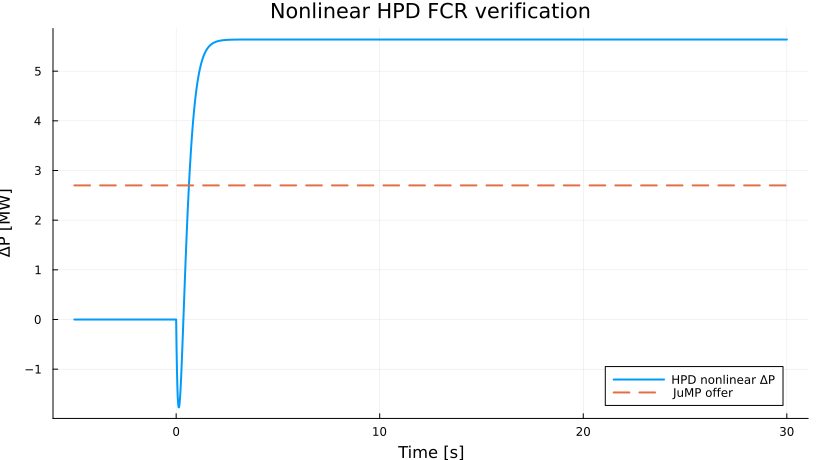

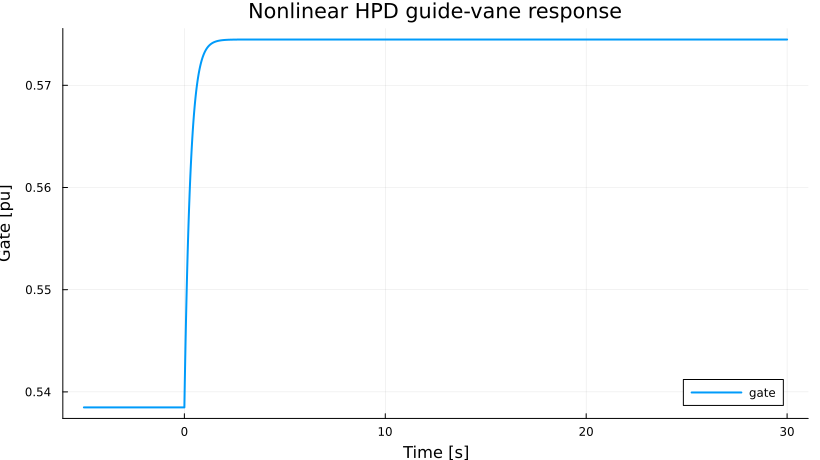

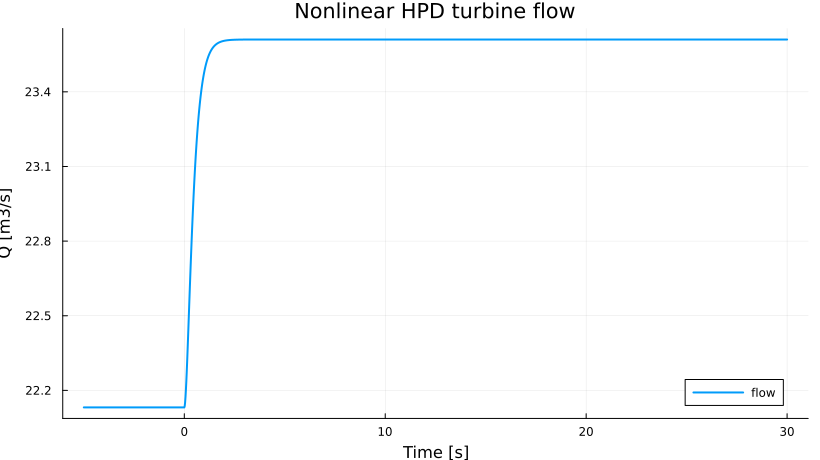

In [7]:
tv=sol.t; keep=findall(>=(-5.0),tv); tt=tv[keep]
pm=sol[nl.turbine.P_mech][keep]./1e6
gate_nl=sol[nl.governor.tau_o][keep]
q_nl=sol[nl.turbine.Q][keep]
pre=findall(x->-5<=x<0,tt); post=findall(>=(0.0),tt)
p0_nl=mean(pm[pre]); dP_nl=pm.-p0_nl
ireq=post[argmin(abs.(tt[post].-T_REQ))]
gate_rate_nl=diff(gate_nl)./diff(tt)
delivery_5=dP_nl[ireq]; delivery_end=dP_nl[last(post)]
pass_delivery=delivery_5 >= ALPHA_REQ*PFCR_star-1e-3
pass_gate=minimum(gate_nl)>=Y_MIN-1e-6 && maximum(gate_nl)<=Y_MAX+1e-6
pass_flow=minimum(q_nl)/Q0>=Q_MIN_PU-1e-3 && maximum(q_nl)/Q0<=Q_MAX_PU+1e-3
pass_rate=maximum(gate_rate_nl)<=DY_OPEN+2e-3 && minimum(gate_rate_nl)>=-DY_CLOSE-2e-3
status=all((pass_delivery,pass_gate,pass_flow,pass_rate)) ? "PASS" : "REDUCE / RETUNE"
summary=DataFrame(metric=["JuMP candidate [MW]","Nonlinear 5 s delivery [MW]","Nonlinear final delivery [MW]","max gate [pu]","max flow/Q0 [pu]","max gate rate [pu/s]","decision"],value=[@sprintf("%.4f",PFCR_star),@sprintf("%.4f",delivery_5),@sprintf("%.4f",delivery_end),@sprintf("%.4f",maximum(gate_nl)),@sprintf("%.4f",maximum(q_nl)/Q0),@sprintf("%.4f",maximum(gate_rate_nl)),status])
display(summary)
p6=plot(tt,dP_nl,xlabel="Time [s]",ylabel="ΔP [MW]",title="Nonlinear HPD FCR verification",label="HPD nonlinear ΔP")
plot!(p6,tt,fill(PFCR_star,length(tt)),linestyle=:dash,label="JuMP offer")
savefig(p6,joinpath(plotdir,"06_nonlinear_power_verification.png")); display(p6)
p7=plot(tt,gate_nl,xlabel="Time [s]",ylabel="Gate [pu]",title="Nonlinear HPD guide-vane response",label="gate")
savefig(p7,joinpath(plotdir,"07_nonlinear_gate.png")); display(p7)
p8=plot(tt,q_nl,xlabel="Time [s]",ylabel="Q [m3/s]",title="Nonlinear HPD turbine flow",label="flow")
savefig(p8,joinpath(plotdir,"08_nonlinear_flow.png")); display(p8)

## 6. Linear screening vs nonlinear physics

A candidate is retained only when the full nonlinear trajectory satisfies the same engineering limits. A mismatch is not hidden; it identifies derating or controller-retuning needs.

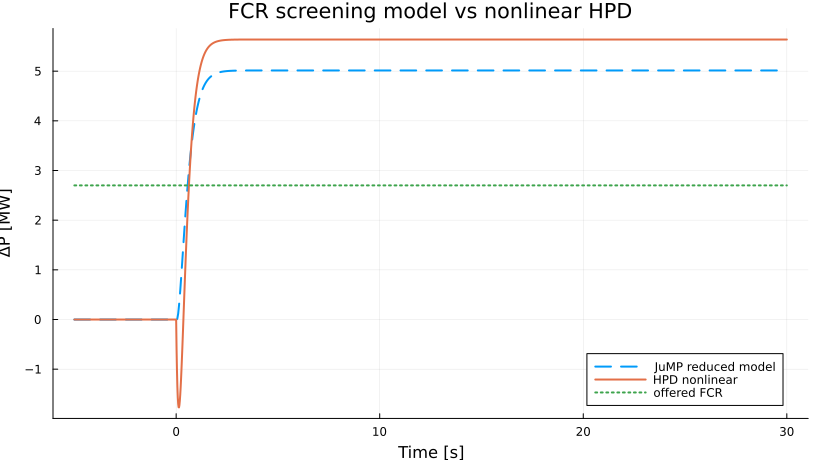

Row,candidate_MW,droop_R_pu,linear_delivery_5s_MW,nonlinear_delivery_5s_MW,nonlinear_final_delivery_MW,max_gate_pu,max_flow_pu,max_gate_rate_pus,decision
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,String
1,2.7,0.0555555,5.01412,5.63724,5.63724,0.57448,1.06653,0.116088,PASS


Final engineering decision: PASS


In [8]:
function interp_linear(tq)
    tq<=times[1] && return dPv[1]
    tq>=times[end] && return dPv[end]
    j=min(searchsortedlast(times,tq),length(times)-1)
    a=(tq-times[j])/(times[j+1]-times[j])
    (1-a)*dPv[j]+a*dPv[j+1]
end
lin_on_nl=[interp_linear(x) for x in tt]
p9=plot(tt,lin_on_nl,linestyle=:dash,label="JuMP reduced model",xlabel="Time [s]",ylabel="ΔP [MW]",title="FCR screening model vs nonlinear HPD")
plot!(p9,tt,dP_nl,label="HPD nonlinear")
plot!(p9,tt,fill(PFCR_star,length(tt)),linestyle=:dot,label="offered FCR")
savefig(p9,joinpath(plotdir,"09_linear_vs_nonlinear.png")); display(p9)
record=DataFrame(candidate_MW=[PFCR_star],droop_R_pu=[R_star],linear_delivery_5s_MW=[dPv[kreq]],nonlinear_delivery_5s_MW=[delivery_5],nonlinear_final_delivery_MW=[delivery_end],max_gate_pu=[maximum(gate_nl)],max_flow_pu=[maximum(q_nl)/Q0],max_gate_rate_pus=[maximum(gate_rate_nl)],decision=[status])
CSV.write(joinpath(resultdir,"fcr_candidate_summary.csv"),record)
traj=DataFrame(time_s=tt,nonlinear_deltaP_MW=dP_nl,nonlinear_gate_pu=gate_nl,nonlinear_Q_m3s=q_nl,linear_deltaP_MW=lin_on_nl)
CSV.write(joinpath(resultdir,"fcr_validation_trajectory.csv"),traj)
display(record)
println("Final engineering decision: ",status)

## 7. Next step toward actual Statnett prequalification

Keep the software layers fixed and replace only the proxy qualification configuration by the applicable FCR-N/FCR-D frequency trajectories, dynamic acceptance regions, operating points, measurement-path treatment and reporting rules. Then run the same JuMP candidate -> nonlinear HPD verification chain for every required test case.